## CUSUM:監控每日下午時段的 hourly PM2.5 是否持續偏高
The standardized hourly PM2.5 value is defined as:

$$
Z_i = \frac{X_i - \mu_h}{\sigma_h}
$$

where $X_i$ is the observed PM2.5 concentration at time $i$, and $\mu_h$ and $\sigma_h$ are the Phase I mean and standard deviation for hour $h$.

The upper CUSUM statistics are calculated as:

$$
C_i^+ = \max(0, C_{i-1}^+ + Z_i - k)
$$

with

$$
C_0^+  = 0.
$$

An out-of-control signal is detected when:

$$
C_i^+ > H
$$


In this study, $k=1$ and $H=10$ were used.

## Phase1

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [119]:
def make_period_hourly_cusum_phase_data(file, start_hour=12, end_hour=17):
    df = pd.read_excel(file)

    df["monitordate"] = pd.to_datetime(df["monitordate"])
    df = df.sort_values("monitordate").reset_index(drop=True)

    df["date"] = df["monitordate"].dt.date
    df["hour"] = df["monitordate"].dt.hour
    df["day"] = df["monitordate"].dt.day

    df_period = df[
        (df["hour"] >= start_hour) &
        (df["hour"] <= end_hour)
    ].copy()

    hourly_data = df_period[[
        "monitordate",
        "date",
        "day",
        "hour",
        "PM2.5"
    ]].copy()

    hourly_data = hourly_data.rename(columns={
        "PM2.5": "pm25"
    })

    print(f"\nHourly PM2.5 data for {file}:")
    print(hourly_data.head())

    print("\nData size:")
    print(hourly_data.shape)

    print("\nHour distribution:")
    print(hourly_data["hour"].value_counts().sort_index())

    print("\nMissing PM2.5 count:")
    print(hourly_data["pm25"].isna().sum())

    return hourly_data


phase1_hourly_data = make_period_hourly_cusum_phase_data(
    "air_quality_202501.xlsx",
    start_hour=12,
    end_hour=17
)

phase2_hourly_data = make_period_hourly_cusum_phase_data(
    "air_quality_202601.xlsx",
    start_hour=12,
    end_hour=17
)


Hourly PM2.5 data for air_quality_202501.xlsx:
           monitordate        date  day  hour  pm25
12 2025-01-01 12:00:00  2025-01-01    1    12   9.0
13 2025-01-01 13:00:00  2025-01-01    1    13  11.0
14 2025-01-01 14:00:00  2025-01-01    1    14  11.0
15 2025-01-01 15:00:00  2025-01-01    1    15  18.0
16 2025-01-01 16:00:00  2025-01-01    1    16  11.0

Data size:
(186, 5)

Hour distribution:
hour
12    31
13    31
14    31
15    31
16    31
17    31
Name: count, dtype: int64

Missing PM2.5 count:
2

Hourly PM2.5 data for air_quality_202601.xlsx:
           monitordate        date  day  hour  pm25
12 2026-01-01 12:00:00  2026-01-01    1    12   4.0
13 2026-01-01 13:00:00  2026-01-01    1    13   7.0
14 2026-01-01 14:00:00  2026-01-01    1    14   8.0
15 2026-01-01 15:00:00  2026-01-01    1    15   8.0
16 2026-01-01 16:00:00  2026-01-01    1    16   7.0

Data size:
(186, 5)

Hour distribution:
hour
12    31
13    31
14    31
15    31
16    31
17    31
Name: count, dtype: int64

Mis

In [120]:
phase1_hourly_baseline = phase1_hourly_data.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline["sd_pm25"] = phase1_hourly_baseline["sd_pm25"].replace(0, np.nan)

print("\nPhase I hourly baseline:")
print(phase1_hourly_baseline)


Phase I hourly baseline:
   hour  mean_pm25   sd_pm25   n
0    12   9.774194  5.613731  31
1    13  11.322581  7.871413  31
2    14  12.833333  9.699212  30
3    15  12.612903  8.807865  31
4    16  12.800000  7.923775  30
5    17  13.193548  8.506544  31


In [121]:
def cusum_limits(hourly_data, baseline, k=0.5, h=5):
    stats = hourly_data.copy()

    stats = stats.merge(
        baseline[["hour", "mean_pm25", "sd_pm25"]],
        on="hour",
        how="left"
    )

    stats["z"] = (stats["pm25"] - stats["mean_pm25"]) / stats["sd_pm25"]

    stats["cusum_pos"] = 0.0
    stats["cusum_neg"] = 0.0

    for i in range(len(stats)):
        if i == 0:
            previous_pos = 0
            previous_neg = 0
        else:
            previous_pos = stats.loc[i - 1, "cusum_pos"]
            previous_neg = stats.loc[i - 1, "cusum_neg"]

        z = stats.loc[i, "z"]
        if pd.isna(z):
            stats.loc[i, "cusum_pos"] = previous_pos
            stats.loc[i, "cusum_neg"] = previous_neg
        else:
            stats.loc[i, "cusum_pos"] = max(
                0,
                previous_pos + z - k
            )

            stats.loc[i, "cusum_neg"] = max(
                0,
                previous_neg - z - k
            )

    stats["decision_limit"] = h
    stats["cl"] = 0

    stats["out_of_control_high"] = stats["cusum_pos"] > h
    stats["out_of_control_low"] = stats["cusum_neg"] > h

    stats["out_of_control_cusum"] = (
        stats["out_of_control_high"] |
        stats["out_of_control_low"]
    )

    return stats

In [122]:
phase1_cusum_stats = cusum_limits(
    phase1_hourly_data,
    phase1_hourly_baseline,
    k=1,
    h=10
)

phase1_cusum_stats = phase1_cusum_stats.reset_index(drop=True)

print("CUSUM out-of-control points:")
print(
    phase1_cusum_stats.loc[
        phase1_cusum_stats["out_of_control_cusum"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "cusum_pos",
            "cusum_neg"
        ]
    ]
)

CUSUM out-of-control points:
            monitordate  hour  pm25         z  cusum_pos  cusum_neg
130 2025-01-22 16:00:00    16  41.0  3.558910  11.115970        0.0
131 2025-01-22 17:00:00    17  47.0  3.974170  14.090140        0.0
132 2025-01-23 12:00:00    12  11.0  0.218359  13.308499        0.0
133 2025-01-23 13:00:00    13   7.0 -0.549149  11.759350        0.0
134 2025-01-23 14:00:00    14   6.0 -0.704525  10.054825        0.0


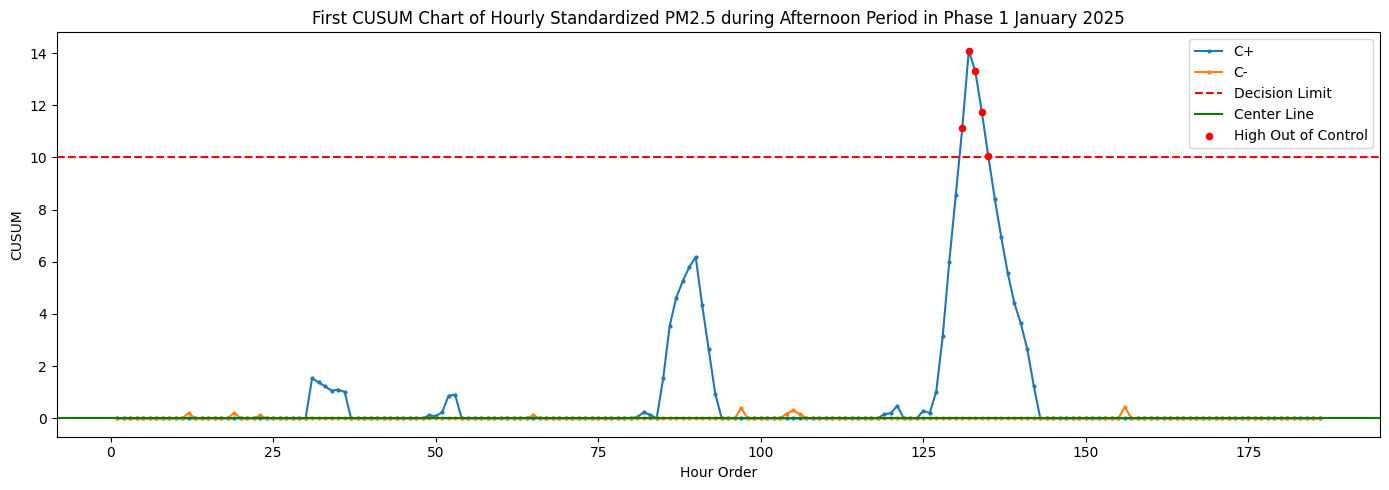

In [123]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_cusum_stats) + 1)
h_value = phase1_cusum_stats["decision_limit"].iloc[0]
plt.plot(
    x,
    phase1_cusum_stats["cusum_pos"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C+"
)

plt.plot(
    x,
    phase1_cusum_stats["cusum_neg"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C-"
)

plt.axhline(
    y=h_value ,
    color="red",
    linestyle="--",
    label="Decision Limit"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_cusum_stats["out_of_control_high"]
out_low = phase1_cusum_stats["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_cusum_stats.loc[out_high, "cusum_pos"],
    color="red",
    s=20,
    zorder=5,
    label="High Out of Control"
)


plt.title("First CUSUM Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("CUSUM")
plt.legend()

plt.tight_layout()
plt.show()

In [124]:
phase1_hourly_clean = phase1_cusum_stats.loc[
    ~phase1_cusum_stats["out_of_control_high"],
    ["monitordate", "date", "day", "hour", "pm25"]
].copy()

phase1_hourly_clean = phase1_hourly_clean.reset_index(drop=True)

In [125]:
phase1_hourly_baseline_clean = phase1_hourly_clean.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline_clean["sd_pm25"] = phase1_hourly_baseline_clean["sd_pm25"].replace(0, np.nan)

phase1_cusum_stats_clean = cusum_limits(
    phase1_hourly_clean,
    phase1_hourly_baseline_clean,
    k=1,
    h=10
)

In [126]:
phase1_cusum_stats_clean = phase1_cusum_stats_clean.reset_index(drop=True)

print("Second CUSUM out-of-control points:")
print(
    phase1_cusum_stats_clean.loc[
        phase1_cusum_stats_clean["out_of_control_cusum"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "cusum_pos",
            "cusum_neg",
            "decision_limit"
        ]
    ]
)

Second CUSUM out-of-control points:
            monitordate  hour  pm25        z  cusum_pos  cusum_neg  \
129 2025-01-22 15:00:00    15  44.0  3.56353  10.071589        0.0   

     decision_limit  
129              10  


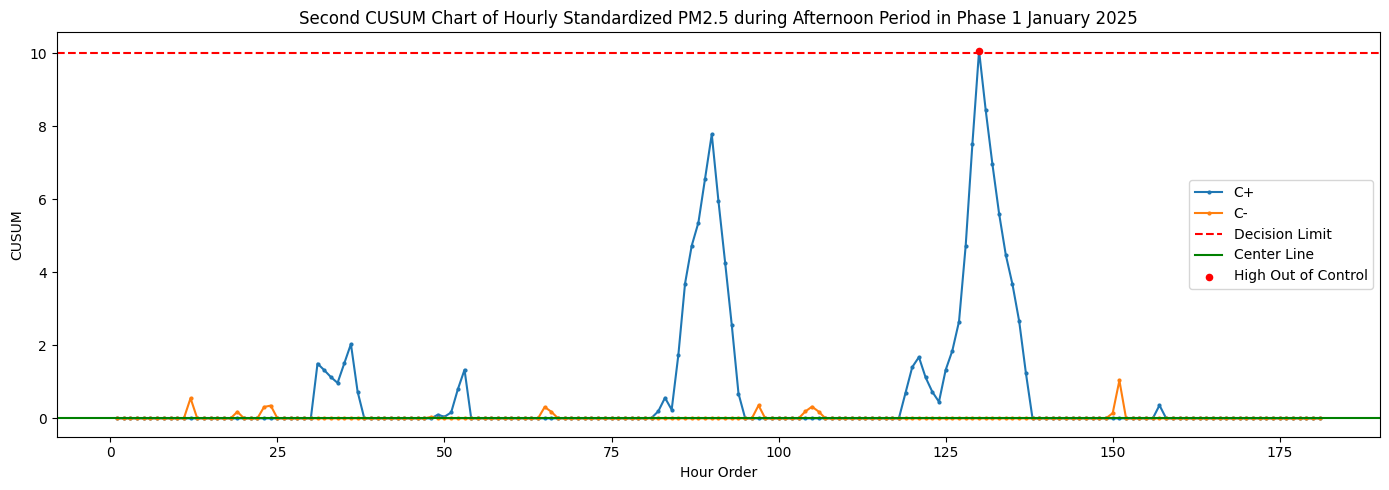

In [127]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_cusum_stats_clean) + 1)
h_value = phase1_cusum_stats_clean["decision_limit"].iloc[0]

plt.plot(
    x,
    phase1_cusum_stats_clean["cusum_pos"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C+"
)

plt.plot(
    x,
    phase1_cusum_stats_clean["cusum_neg"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C-"
)

plt.axhline(
    y=h_value,
    color="red",
    linestyle="--",
    label="Decision Limit"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_cusum_stats_clean["out_of_control_high"]
out_low = phase1_cusum_stats_clean["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_cusum_stats_clean.loc[out_high, "cusum_pos"],
    color="red",
    s=20,
    zorder=5,
    label="High Out of Control"
)

plt.title("Second CUSUM Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("CUSUM")
plt.legend()

plt.tight_layout()
plt.show()

In [128]:
phase1_hourly_clean2 = phase1_cusum_stats_clean.loc[
    ~phase1_cusum_stats_clean["out_of_control_high"],
    ["monitordate", "date", "day", "hour", "pm25"]
].copy()

phase1_hourly_clean2 = phase1_hourly_clean2.reset_index(drop=True)

phase1_hourly_baseline_clean2 = phase1_hourly_clean2.groupby("hour").agg(
    mean_pm25=("pm25", "mean"),
    sd_pm25=("pm25", "std"),
    n=("pm25", "count")
).reset_index()

phase1_hourly_baseline_clean2["sd_pm25"] = phase1_hourly_baseline_clean2["sd_pm25"].replace(0, np.nan)

phase1_cusum_stats_clean2 = cusum_limits(
    phase1_hourly_clean2,
    phase1_hourly_baseline_clean2,
    k=1,
    h=10
)

In [129]:

print("Third CUSUM out-of-control points:")
print(
    phase1_cusum_stats_clean2.loc[
        phase1_cusum_stats_clean2["out_of_control_cusum"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "cusum_pos",
            "cusum_neg",
            "decision_limit"
        ]
    ]
)

Third CUSUM out-of-control points:
Empty DataFrame
Columns: [monitordate, hour, pm25, z, cusum_pos, cusum_neg, decision_limit]
Index: []


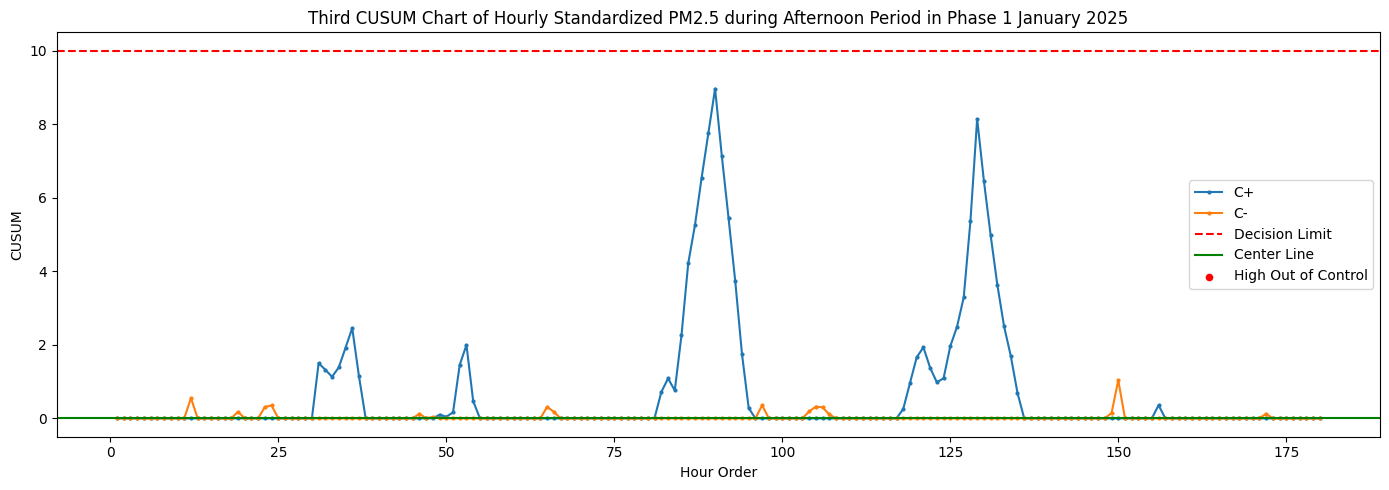

In [130]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase1_cusum_stats_clean2) + 1)
h_value = phase1_cusum_stats_clean2["decision_limit"].iloc[0]

plt.plot(
    x,
    phase1_cusum_stats_clean2["cusum_pos"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C+"
)

plt.plot(
    x,
    phase1_cusum_stats_clean2["cusum_neg"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C-"
)

plt.axhline(
    y=h_value,
    color="red",
    linestyle="--",
    label="Decision Limit"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase1_cusum_stats_clean2["out_of_control_high"]
out_low = phase1_cusum_stats_clean2["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase1_cusum_stats_clean2.loc[out_high, "cusum_pos"],
    color="red",
    s=20,
    zorder=5,
    label="High Out of Control"
)

plt.title("Third CUSUM Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 1 January 2025")
plt.xlabel("Hour Order")
plt.ylabel("CUSUM")
plt.legend()

plt.tight_layout()
plt.show()

## Phase 2

In [131]:
phase2_cusum = phase2_hourly_data.copy()
phase2_cusum = phase2_cusum.reset_index(drop=True)

# 使用 Phase 1 revised baseline，也就是排除 2025-01-22 後的 p_bar_clean
#phase2_p = pchart_limits(phase2_p, p_bar_clean)
phase2_cusum = cusum_limits(
    phase2_cusum,
    phase1_hourly_baseline_clean2,
    k=1,
    h=10
)

phase2_cusum = phase2_cusum.reset_index(drop=True)

print("CUSUM out-of-control points:")
print(
    phase2_cusum.loc[
        phase2_cusum["out_of_control_cusum"],
        [
            "monitordate",
            "hour",
            "pm25",
            "z",
            "cusum_pos",
            "cusum_neg"
        ]
    ]
)

CUSUM out-of-control points:
           monitordate  hour  pm25         z  cusum_pos  cusum_neg
33 2026-01-06 15:00:00    15  36.0  3.636228  10.007853    0.00000
34 2026-01-06 16:00:00    16  44.0  5.388494  14.396346    0.00000
35 2026-01-06 17:00:00    17  32.0  3.411855  16.808202    0.00000
36 2026-01-07 12:00:00    12  24.0  2.500726  18.308928    0.00000
37 2026-01-07 13:00:00    13  19.0  0.945889  18.254817    0.00000
38 2026-01-07 14:00:00    14  27.0  1.423987  18.678805    0.00000
39 2026-01-07 15:00:00    15  22.0  1.552714  19.231519    0.00000
40 2026-01-07 16:00:00    16  21.0  1.536269  19.767788    0.00000
41 2026-01-07 17:00:00    17  22.0  1.700222  20.468010    0.00000
42 2026-01-08 12:00:00    12  24.0  2.500726  21.968736    0.00000
43 2026-01-08 13:00:00    13  17.0  0.694768  21.663505    0.00000
44 2026-01-08 14:00:00    14  19.0  0.606252  21.269757    0.00000
45 2026-01-08 15:00:00    15  20.0  1.255069  21.524826    0.00000
46 2026-01-08 16:00:00    16  17.

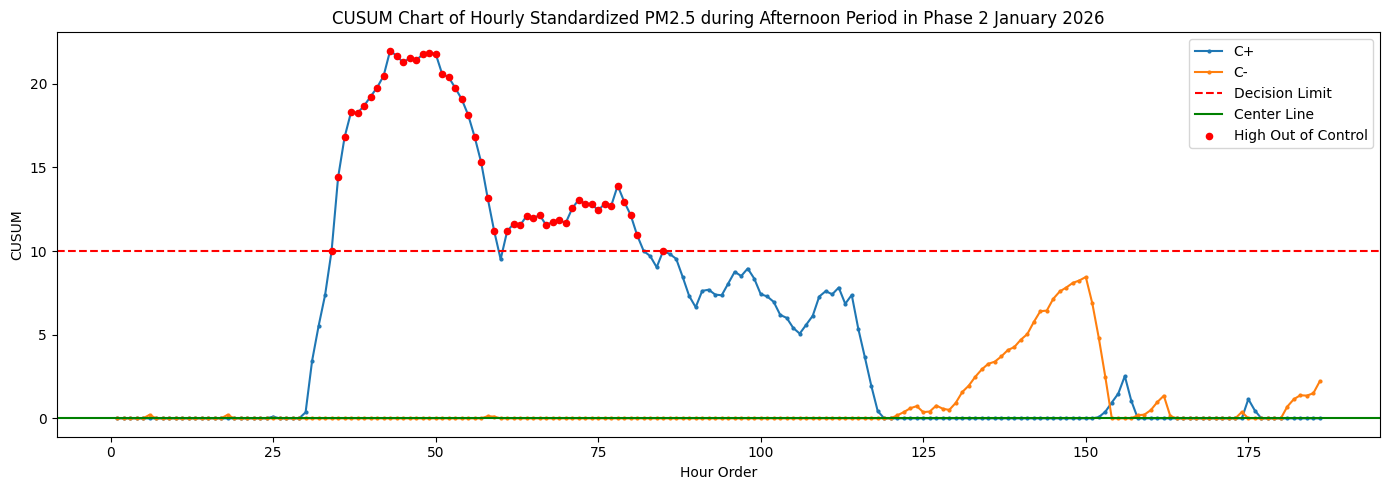

In [132]:
plt.figure(figsize=(14, 5))

x = np.arange(1, len(phase2_cusum) + 1)
h_value = phase2_cusum["decision_limit"].iloc[0]

plt.plot(
    x,
    phase2_cusum["cusum_pos"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C+"
)

plt.plot(
    x,
    phase2_cusum["cusum_neg"],
    marker="o",
    markersize=2,
    linestyle="-",
    label="C-"
)

plt.axhline(
    y=h_value,
    color="red",
    linestyle="--",
    label="Decision Limit"
)

plt.axhline(
    y=0,
    color="green",
    linestyle="-",
    label="Center Line"
)

out_high = phase2_cusum["out_of_control_high"]
out_low = phase2_cusum["out_of_control_low"]

plt.scatter(
    x[out_high],
    phase2_cusum.loc[out_high, "cusum_pos"],
    color="red",
    s=20,
    zorder=5,
    label="High Out of Control"
)

plt.title("CUSUM Chart of Hourly Standardized PM2.5 during Afternoon Period in Phase 2 January 2026")
plt.xlabel("Hour Order")
plt.ylabel("CUSUM")
plt.legend()

plt.tight_layout()
plt.show()

### Summary

In [133]:
phase2_high_signal = phase2_cusum.loc[
    phase2_cusum["out_of_control_high"],
    ["monitordate", "date", "hour", "pm25", "z", "cusum_pos"]
].copy()

print("Phase II high CUSUM signal points:")
print(phase2_high_signal)

print("\nSignal period:")
print("Start time:", phase2_high_signal["monitordate"].min())
print("End time:", phase2_high_signal["monitordate"].max())
print("Maximum C+:", phase2_high_signal["cusum_pos"].max())

Phase II high CUSUM signal points:
           monitordate        date  hour  pm25         z  cusum_pos
33 2026-01-06 15:00:00  2026-01-06    15  36.0  3.636228  10.007853
34 2026-01-06 16:00:00  2026-01-06    16  44.0  5.388494  14.396346
35 2026-01-06 17:00:00  2026-01-06    17  32.0  3.411855  16.808202
36 2026-01-07 12:00:00  2026-01-07    12  24.0  2.500726  18.308928
37 2026-01-07 13:00:00  2026-01-07    13  19.0  0.945889  18.254817
38 2026-01-07 14:00:00  2026-01-07    14  27.0  1.423987  18.678805
39 2026-01-07 15:00:00  2026-01-07    15  22.0  1.552714  19.231519
40 2026-01-07 16:00:00  2026-01-07    16  21.0  1.536269  19.767788
41 2026-01-07 17:00:00  2026-01-07    17  22.0  1.700222  20.468010
42 2026-01-08 12:00:00  2026-01-08    12  24.0  2.500726  21.968736
43 2026-01-08 13:00:00  2026-01-08    13  17.0  0.694768  21.663505
44 2026-01-08 14:00:00  2026-01-08    14  19.0  0.606252  21.269757
45 2026-01-08 15:00:00  2026-01-08    15  20.0  1.255069  21.524826
46 2026-01-08

In [134]:
phase2_cusum["new_high_signal"] = (
    phase2_cusum["out_of_control_high"] &
    ~phase2_cusum["out_of_control_high"].shift(fill_value=False)
)

phase2_cusum["high_signal_group"] = (
    phase2_cusum["new_high_signal"].cumsum()
)

phase2_high_cusum_periods = (
    phase2_cusum.loc[phase2_cusum["out_of_control_high"]]
    .groupby("high_signal_group")
    .agg(
        start_time=("monitordate", "first"),
        end_time=("monitordate", "last"),
        start_date=("date", "first"),
        end_date=("date", "last"),
        start_hour=("hour", "first"),
        end_hour=("hour", "last"),
        signal_count=("monitordate", "count"),
        max_pm25=("pm25", "max"),
        max_z=("z", "max"),
        max_cusum_pos=("cusum_pos", "max")
    )
    .reset_index(drop=True)
)

print("\nPhase II high CUSUM signal periods:")
print(phase2_high_cusum_periods)


Phase II high CUSUM signal periods:
           start_time            end_time  start_date    end_date  start_hour  \
0 2026-01-06 15:00:00 2026-01-10 16:00:00  2026-01-06  2026-01-10          15   
1 2026-01-11 12:00:00 2026-01-14 14:00:00  2026-01-11  2026-01-14          12   
2 2026-01-15 12:00:00 2026-01-15 12:00:00  2026-01-15  2026-01-15          12   

   end_hour  signal_count  max_pm25     max_z  max_cusum_pos  
0        16            26      44.0  5.388494      21.968736  
1        14            21      25.0  2.676011      13.907380  
2        12             1      21.0  1.974873      10.004273  
